# Why is LFM2.5-VL-1.6B faster than the smaller Qwen3.5-0.8B? — per-stage & per-layer latency

A pure-curiosity profiler. Qwen3.5-VL **0.8B** has *fewer parameters* than LFM2.5-VL **1.6B**, yet in
the full comparison LFM was the faster model (~1 s/sample vs ~14 s/sample for Qwen). This notebook
finds **where** the wall-clock goes, on **one** document image, and tests two hypotheses:

* **H1 — vision-token count.** Qwen3.5-VL uses dynamic resolution (`smart_resize`) and can expand a
  full-page document into **thousands** of vision tokens, while LFM2.5-VL (SigLIP2 + token merging,
  edge-oriented) emits far fewer -> Qwen's **prefill** attention context is much longer (~quadratic).
* **H2 — per-layer cost.** LFM2 is a **hybrid-conv** backbone (short convolutions + few attention
  layers); per LLM layer it can be cheaper than Qwen's full self-attention, so even at 2x params the
  per-token decode cost is lower.

We measure: token counts (vision / prompt / generated), stage wall-clock
(preprocess -> prefill -> decode), and **per-layer** time during prefill (vision encoder vs connector
vs LLM), with CUDA events. **GPU required** for meaningful numbers. Run order: Runtime -> Run all.

In [ ]:
# --- install docvlm_eval + ALWAYS sync to latest pushed code + GUARANTEE transformers>=5 ---
import os, sys, subprocess, importlib
from pathlib import Path
BRANCH = "claude/new-session-w79q0i"

def _repo_root():
    for c in (Path.cwd(), Path.cwd().parent):
        if (c / "pyproject.toml").exists():
            return c
    return None

root = _repo_root()
if root is None:                       # fresh env (Colab/Kaggle): clone the repo
    subprocess.run(["git", "clone", "https://github.com/SangbumChoi/OCR.git"], check=False)
    root = Path("OCR")
root = str(root)
# a persistent runtime keeps an OLD clone -> stale scripts; always fetch + checkout + ff (else reset).
subprocess.run(["git", "-C", root, "fetch", "origin", BRANCH], check=False)
subprocess.run(["git", "-C", root, "checkout", BRANCH], check=False)
if subprocess.run(["git", "-C", root, "pull", "--ff-only", "origin", BRANCH]).returncode != 0:
    print(f"ff-only pull failed -> hard-resetting the clone to origin/{BRANCH}")
    subprocess.run(["git", "-C", root, "reset", "--hard", f"origin/{BRANCH}"], check=False)
subprocess.run(["git", "-C", root, "--no-pager", "log", "-1", "--oneline"], check=False)
os.chdir(root)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[newvlms]"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=5", "torchao>=0.16.0", "accelerate"], check=True)

if "transformers" in sys.modules:
    import transformers as _tf
    if int(_tf.__version__.split(".")[0]) < 5:
        print(f"transformers {_tf.__version__} loaded in-kernel; upgraded on disk -> RESTARTING. Re-run this cell.")
        os._exit(0)

src = str(Path.cwd() / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()
import torch, transformers
print("transformers", transformers.__version__, "| torch", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "|", (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU - numbers will be CPU-bound, profile is still directional"))
assert int(transformers.__version__.split(".")[0]) >= 5, "need transformers>=5"

## 1. The two models + one document image

We profile **one model at a time** (load -> profile -> free) so a single 16 GB GPU (T4) is enough.

In [2]:
ROOT = Path.cwd()
if not (ROOT/"scripts").exists() and (ROOT.parent/"scripts").exists():
    ROOT = ROOT.parent

HF_ID = {
    "qwen3_5-0.8b":   "Qwen/Qwen3.5-0.8B",        # Qwen3.5-VL, ~0.87B, dynamic-resolution vision
    "lfm2_5-vl-1.6b": "LiquidAI/LFM2.5-VL-1.6B",  # LFM2 hybrid-conv backbone + SigLIP2, ~1.6B
}
MODELS = ["qwen3_5-0.8b", "lfm2_5-vl-1.6b"]
COLOR  = {"qwen3_5-0.8b": "#d7791d", "lfm2_5-vl-1.6b": "#1f77b4"}

# one realistic full-page document (the harder, vision-token-heavy case). Fall back to any png.
cand = [ROOT/"data"/"probes"/"realistic_cases"/"invoice"/"clean.png",
        ROOT/"data"/"probes"/"realistic_cases"/"pdf_paper"/"clean.png"]
IMG_PATH = next((p for p in cand if p.exists()), None)
if IMG_PATH is None:
    IMG_PATH = next(iter((ROOT/"data"/"probes"/"realistic_cases").rglob("clean.png")))
QUESTION = "What is the total amount? Read the document and answer concisely."
print("image:", IMG_PATH, "\nquestion:", QUESTION)


image: /content/OCR/data/probes/realistic_cases/invoice/clean.png 
question: What is the total amount? Read the document and answer concisely.


## 2. Profilers - CUDA-event stage timer + per-layer forward hooks

`_comp()` reuses the project's module-path buckets (vision / connector / llm) from
`finetune.lora_vlm` so per-layer times attribute to the right component on **either** architecture
with no per-model name tables.

In [3]:
import re, time
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor
try:
    from transformers import AutoModelForImageTextToText as AutoVLM
except ImportError:
    from transformers import AutoModelForVision2Seq as AutoVLM

# component classification (same regexes as finetune.lora_vlm._bucket)
_VIS = re.compile(r"vis(ual|ion)|patch|siglip|navit|aimv2", re.I)
_CON = re.compile(r"merger|projector|connector|mlp1|multi_modal|abstractor|resampler", re.I)
_BLOCK = re.compile(r"\.(layers|blocks|h)\.\d+$")   # one transformer block (ModuleList element)

def _comp(name):
    if _CON.search(name): return "connector"
    if _VIS.search(name): return "vision"
    return "llm"

CUDA = torch.cuda.is_available()

def gpu_time(fn, warmup=1, iters=3):
    """Mean wall-time (s) of fn(), CUDA-event timed with sync (or perf_counter on CPU)."""
    for _ in range(warmup): fn()
    if CUDA:
        torch.cuda.synchronize(); s = torch.cuda.Event(True); e = torch.cuda.Event(True); ts = []
        for _ in range(iters):
            s.record(); fn(); e.record(); torch.cuda.synchronize(); ts.append(s.elapsed_time(e)/1000.0)
        return float(np.mean(ts))
    ts = []
    for _ in range(iters):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter()-t0)
    return float(np.mean(ts))

class LayerProfiler:
    """Forward hooks on every transformer block (+ the connector) -> per-module time for ONE pass."""
    def __init__(self, model):
        self.h = []; self.start = {}; self.records = []
        names = [n for n,_ in model.named_modules()]
        con = min([n for n in names if _CON.search(n)], key=len, default=None)  # shallowest connector
        for name, mod in model.named_modules():
            if _BLOCK.search(name) or name == con:
                self.h.append(mod.register_forward_pre_hook(self._pre(name)))
                self.h.append(mod.register_forward_hook(self._post(name)))
    def _pre(self, name):
        def f(m, inp):
            if CUDA: ev = torch.cuda.Event(True); ev.record(); self.start[name] = ev
            else: self.start[name] = time.perf_counter()
        return f
    def _post(self, name):
        def f(m, inp, out):
            a = self.start.pop(name, None)
            if a is None: return
            if CUDA: ev = torch.cuda.Event(True); ev.record(); self.records.append((name, a, ev))
            else: self.records.append((name, a, time.perf_counter()))
        return f
    def finalize(self):
        if CUDA: torch.cuda.synchronize()
        out = []
        for name, a, b in self.records:
            ms = a.elapsed_time(b) if CUDA else (b - a)*1000.0
            out.append((name, _comp(name), ms))
        return out
    def remove(self):
        for h in self.h: h.remove()

def image_token_id(model, proc):
    for obj in (model.config, getattr(model.config, "vision_config", None), getattr(model.config, "text_config", None)):
        if obj is None: continue
        for attr in ("image_token_id", "image_token_index", "image_token"):
            v = getattr(obj, attr, None)
            if isinstance(v, int): return v
    for tok in ("<image>", "<|image_pad|>", "<|image|>", "<image_soft_token>"):
        try:
            i = proc.tokenizer.convert_tokens_to_ids(tok)
            if i is not None and i >= 0: return i
        except Exception: pass
    return None

def param_breakdown(model):
    agg = defaultdict(int)
    for n, p in model.named_parameters(): agg[_comp(n)] += p.numel()
    return dict(agg)


## 3. Profile each model on the single image

For each model: count tokens, time **preprocess**, **prefill** (one forward), and **decode**
(generate - prefill), and capture **per-layer** prefill time. Then free the model.

In [ ]:
def profile_model(key, max_new_tokens=64, decode_k=32):
    hf = HF_ID[key]; print(f"\n=== {key} ({hf}) ===")
    proc = AutoProcessor.from_pretrained(hf, trust_remote_code=True)
    dt = torch.bfloat16 if CUDA else torch.float32
    model = AutoVLM.from_pretrained(hf, dtype=dt, trust_remote_code=True, low_cpu_mem_usage=True)
    model = model.to("cuda" if CUDA else "cpu").eval()

    img = Image.open(IMG_PATH).convert("RGB")
    msgs = [{"role":"user","content":[{"type":"image","image":img},{"type":"text","text":QUESTION}]}]
    build = lambda: proc.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True,
                                             return_dict=True, return_tensors="pt")
    pre_s = gpu_time(build, warmup=1, iters=3)                  # processor (CPU-side) cost
    inputs = {k: (v.to(model.device) if hasattr(v,"to") else v) for k,v in build().items()}
    ids = inputs["input_ids"]; n_prompt = ids.shape[1]
    itid = image_token_id(model, proc)
    n_vis = int((ids == itid).sum()) if itid is not None else None

    @torch.no_grad()
    def prefill(): model(**inputs)
    pf_s = gpu_time(prefill, warmup=1, iters=3)                 # one forward = the prefill cost

    # natural answer length (greedy; may stop at EOS early)
    @torch.no_grad()
    def gen_natural(): return model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    n_gen = int(gen_natural().shape[1] - n_prompt)
    # isolate DECODE: time a FORCED 1-token vs decode_k-token generate -> per-token decode cost.
    # (subtracting a separately-measured prefill clamps to 0 when decode << prefill — the old bug.)
    @torch.no_grad()
    def gen_fixed(k): return model.generate(**inputs, min_new_tokens=k, max_new_tokens=k, do_sample=False)
    t1 = gpu_time(lambda: gen_fixed(1), warmup=1, iters=2)
    tk = gpu_time(lambda: gen_fixed(decode_k), warmup=0, iters=2)
    dec_per_tok = max((tk - t1) / max(decode_k - 1, 1), 0.0)
    dec_s = dec_per_tok * max(n_gen, 1)                         # decode time for this image's answer

    prof = LayerProfiler(model)                                  # per-layer (one prefill pass)
    with torch.no_grad(): prefill()
    per_layer = prof.finalize(); prof.remove()

    params = param_breakdown(model)
    res = dict(key=key, n_vision=n_vis, n_prompt=n_prompt, n_gen=n_gen,
               pre_s=pre_s, prefill_s=pf_s, decode_s=dec_s, dec_per_tok=dec_per_tok,
               per_layer=per_layer, params=params,
               n_llm_layers=sum(1 for n,c,_ in per_layer if c=="llm"),
               n_vis_layers=sum(1 for n,c,_ in per_layer if c=="vision"))
    print(f"  vision_tokens={n_vis}  prompt_tokens={n_prompt}  gen_tokens={n_gen}")
    print(f"  preprocess={pre_s*1000:.0f}ms  prefill={pf_s*1000:.0f}ms  "
          f"decode={dec_per_tok*1000:.1f}ms/tok (x{n_gen} = {dec_s*1000:.0f}ms)")
    print(f"  params(M): " + ", ".join(f"{k}={v/1e6:.0f}" for k,v in params.items()))
    del model
    if CUDA: torch.cuda.empty_cache()
    return res

RES = {m: profile_model(m) for m in MODELS}
print("\ndone - RES has:", list(RES))

## 4. Token counts - the prefill driver (H1)

If Qwen emits far more **vision tokens** than LFM, its prefill attention context (and KV-cache) is
much larger - the first thing to check.

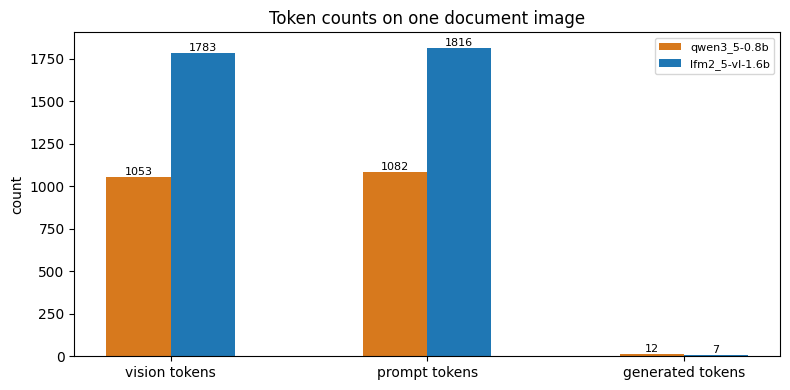

qwen3_5-0.8b     vision_tokens=1053  (prompt=1082, gen=12)
lfm2_5-vl-1.6b   vision_tokens=1783  (prompt=1816, gen=7)


In [5]:
fig, ax = plt.subplots(figsize=(8,4)); w=0.25; x=np.arange(3)
labels=["vision tokens","prompt tokens","generated tokens"]
for i,m in enumerate(MODELS):
    r=RES[m]; vals=[r["n_vision"] or 0, r["n_prompt"], r["n_gen"]]
    b=ax.bar(x+(i-0.5)*w, vals, w, label=m, color=COLOR[m])
    ax.bar_label(b, fmt="%d", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("count"); ax.set_title("Token counts on one document image")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
for m in MODELS:
    r=RES[m]; print(f"{m:16} vision_tokens={r['n_vision']}  (prompt={r['n_prompt']}, gen={r['n_gen']})")


## 5. Stage wall-clock - preprocess / prefill / decode

Where does the *time* actually go? Decode scales with **generated tokens x per-token cost**; prefill
scales with **context length** (~ vision tokens).

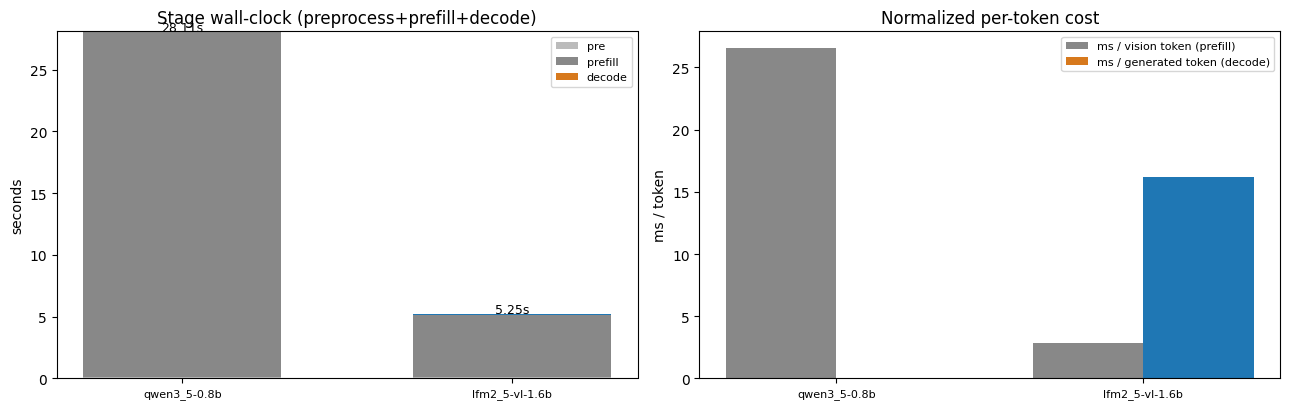

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4.2))
# (a) stacked stage time
for i,m in enumerate(MODELS):
    r=RES[m]; bottom=0
    for stage,c in [("pre_s","#bbbbbb"),("prefill_s","#888888"),("decode_s",COLOR[m])]:
        ax[0].bar(i, r[stage], 0.6, bottom=bottom, color=c,
                  label=stage.replace("_s","") if i==0 else None)
        bottom+=r[stage]
    ax[0].text(i, bottom+0.02, f"{bottom:.2f}s", ha="center", fontsize=9)
ax[0].set_xticks(range(len(MODELS))); ax[0].set_xticklabels(MODELS, fontsize=8)
ax[0].set_ylabel("seconds"); ax[0].set_title("Stage wall-clock (preprocess+prefill+decode)"); ax[0].legend(fontsize=8)
# (b) per-token normalization
for i,m in enumerate(MODELS):
    r=RES[m]
    ms_vis = (r["prefill_s"]/r["n_vision"]*1000) if r["n_vision"] else 0
    ms_gen = (r["decode_s"]/r["n_gen"]*1000) if r["n_gen"] else 0
    ax[1].bar(i-0.18, ms_vis, 0.36, color="#888888", label="ms / vision token (prefill)" if i==0 else None)
    ax[1].bar(i+0.18, ms_gen, 0.36, color=COLOR[m], label="ms / generated token (decode)" if i==0 else None)
ax[1].set_xticks(range(len(MODELS))); ax[1].set_xticklabels(MODELS, fontsize=8)
ax[1].set_ylabel("ms / token"); ax[1].set_title("Normalized per-token cost"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 6. Per-layer prefill time + per-component split (H2)

Per-layer time during one prefill pass. If LFM's LLM layers are individually cheaper (hybrid-conv vs
full attention), that shows up here even though LFM has more of them / more params.

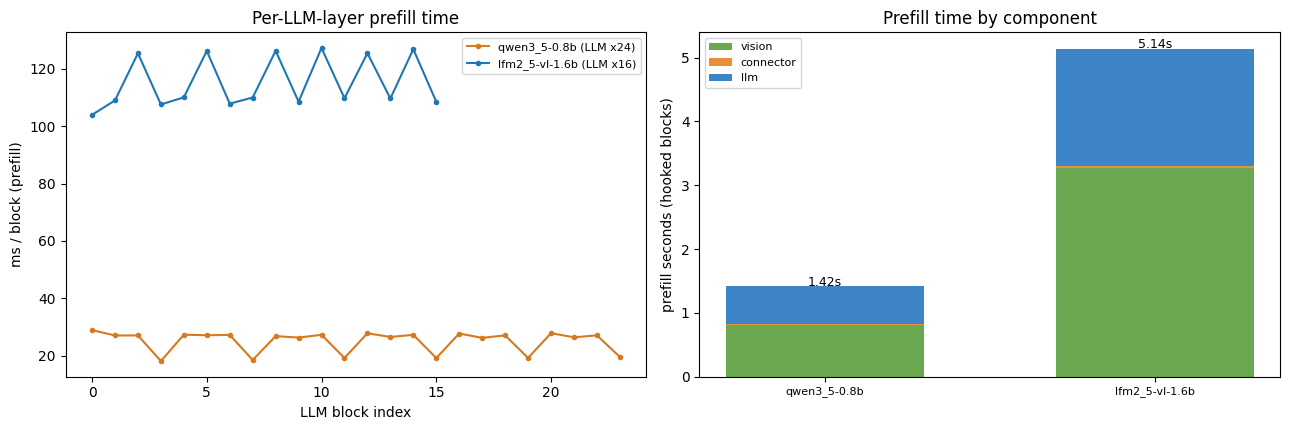

qwen3_5-0.8b     prefill-by-comp(ms): vision=808, connector=11, llm=605  | llm_layers=24 vis_layers=12
lfm2_5-vl-1.6b   prefill-by-comp(ms): vision=3271, connector=26, llm=1841  | llm_layers=16 vis_layers=27


In [7]:
fig, ax = plt.subplots(1,2, figsize=(13,4.4))
# (a) per-layer line, llm blocks ordered
for m in MODELS:
    llm=[ms for n,c,ms in RES[m]["per_layer"] if c=="llm"]
    ax[0].plot(range(len(llm)), llm, "-o", ms=3, label=f"{m} (LLM x{len(llm)})", color=COLOR[m])
ax[0].set_xlabel("LLM block index"); ax[0].set_ylabel("ms / block (prefill)")
ax[0].set_title("Per-LLM-layer prefill time"); ax[0].legend(fontsize=8)
# (b) per-component stacked
comps=["vision","connector","llm"]
for i,m in enumerate(MODELS):
    agg=defaultdict(float)
    for n,c,ms in RES[m]["per_layer"]: agg[c]+=ms
    bottom=0
    for c,col in zip(comps, ["#6aa84f","#e69138","#3d85c6"]):
        ax[1].bar(i, agg[c]/1000, 0.6, bottom=bottom, color=col, label=c if i==0 else None)
        bottom+=agg[c]/1000
    ax[1].text(i, bottom+0.005, f"{bottom:.2f}s", ha="center", fontsize=9)
ax[1].set_xticks(range(len(MODELS))); ax[1].set_xticklabels(MODELS, fontsize=8)
ax[1].set_ylabel("prefill seconds (hooked blocks)"); ax[1].set_title("Prefill time by component"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
for m in MODELS:
    agg=defaultdict(float)
    for n,c,ms in RES[m]["per_layer"]: agg[c]+=ms
    print(f"{m:16} prefill-by-comp(ms): " + ", ".join(f"{c}={agg[c]:.0f}" for c in comps) +
          f"  | llm_layers={RES[m]['n_llm_layers']} vis_layers={RES[m]['n_vis_layers']}")


## 7. Verdict - data-driven summary

The cell prints the measured drivers and an automatic interpretation. The two hypotheses are
*orthogonal*: H1 (vision tokens) explains **prefill**, H2 (per-layer cost) explains **decode**.

In [ ]:
print("model            tot_s  pre  prefill decode | vis_tok gen_tok | ms/vistok ms/gentok | params(M)")
for m in MODELS:
    r=RES[m]; tot=r["pre_s"]+r["prefill_s"]+r["decode_s"]; P=sum(r["params"].values())/1e6
    mv=(r["prefill_s"]/r["n_vision"]*1000) if r["n_vision"] else float("nan")
    mg=r.get("dec_per_tok",0)*1000
    print(f"{m:16}{tot:6.2f}{r['pre_s']:5.2f}{r['prefill_s']:8.2f}{r['decode_s']:7.2f} | "
          f"{str(r['n_vision']):>7}{r['n_gen']:>8} | {mv:9.2f}{mg:10.2f} | {P:8.0f}")

q,l = RES.get("qwen3_5-0.8b"), RES.get("lfm2_5-vl-1.6b")
if q and l:
    print("\n--- interpretation ---")
    # H1 — token COUNT (refuted if LFM has >= tokens yet is faster)
    print(f"H1 vision-token COUNT: qwen={q['n_vision']} vs lfm={l['n_vision']} -> "
          + ("NOT the driver (LFM emits >= tokens yet is faster)" if (l['n_vision'] or 0) >= (q['n_vision'] or 0)
             else "qwen has more tokens"))
    # the real driver — PREFILL compute per vision-token
    qv=q['prefill_s']/max(q['n_vision'] or 1,1)*1000; lv=l['prefill_s']/max(l['n_vision'] or 1,1)*1000
    qshare=q['prefill_s']/max(q['pre_s']+q['prefill_s']+q['decode_s'],1e-9)
    print(f"PREFILL per vision-token: qwen={qv:.1f}ms vs lfm={lv:.1f}ms (qwen {qv/max(lv,1e-9):.1f}x) "
          f"; prefill is {qshare:.0%} of qwen's wall-clock")
    # H2 — DECODE per token (now measured by forced 1-vs-K, not the old clamp-to-0 subtraction)
    qg=q.get('dec_per_tok',0)*1000; lg=l.get('dec_per_tok',0)*1000
    print(f"DECODE per token: qwen={qg:.1f}ms vs lfm={lg:.1f}ms")
    print("\n=> bottleneck = PREFILL compute per token (full self-attention + the ViT), NOT token count; "
          "LFM2's hybrid-conv backbone makes prefill far cheaper per token even at 2x params.")
    print("   levers for qwen latency: cap vision tokens (A7 target_long_side/tiling), shorter targets (A6).")

### What to read off this notebook

- **If qwen's `vision_tokens` >> lfm's** -> H1 holds: Qwen's dynamic-resolution tokenizer makes the
  prefill context (and KV-cache) far larger, so the *smaller* model does *more* attention work on the
  same image. Lever: cap `target_long_side` / tiling (A7), or fewer vision tokens.
- **If qwen's `ms/generated-token` > lfm's** -> H2 holds: LFM2's hybrid-conv layers decode cheaper per
  token than Qwen's full self-attention, so 2x params still runs faster. Lever for Qwen: shorter
  targets / smaller LoRA rank (A6), speculative decode.
- These map straight onto the ablation plan's **latency** row (A6/A7). The numbers here are for one
  image; rerun with different `IMG_PATH` / `max_new_tokens` to see prefill-bound vs decode-bound
  regimes.